In [68]:
import numpy as np
import pandas as pd

# load the dataset
df = pd.read_csv(r'../dataset/diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [69]:
import matplotlib.pyplot as plt 
from sklearn import tree
from sklearn.model_selection import train_test_split

# Preenchimento dos zeros inválidos com a mediana

df['Glucose'] = df['Glucose'].replace(0, df['Glucose'].median())
df['BloodPressure'] = df['BloodPressure'].replace(0, df['BloodPressure'].median())
df['SkinThickness'] = df['SkinThickness'].replace(0, df['SkinThickness'].median())
df['Insulin'] = df['Insulin'].replace(0, df['Insulin'].median())
df['BMI'] = df['BMI'].replace(0, df['BMI'].median())

# Separar as features e o target
x = df.drop('Outcome', axis=1)
y = df['Outcome']

# Dividir o dataset em treino e teste
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Treinar o modelo de árvore de decisão
clf = tree.DecisionTreeClassifier(max_depth=3)
clf.fit(x_train, y_train)

# Fazer previsões
y_pred = clf.predict(x_test)
y_pred_train = clf.predict(x_train)

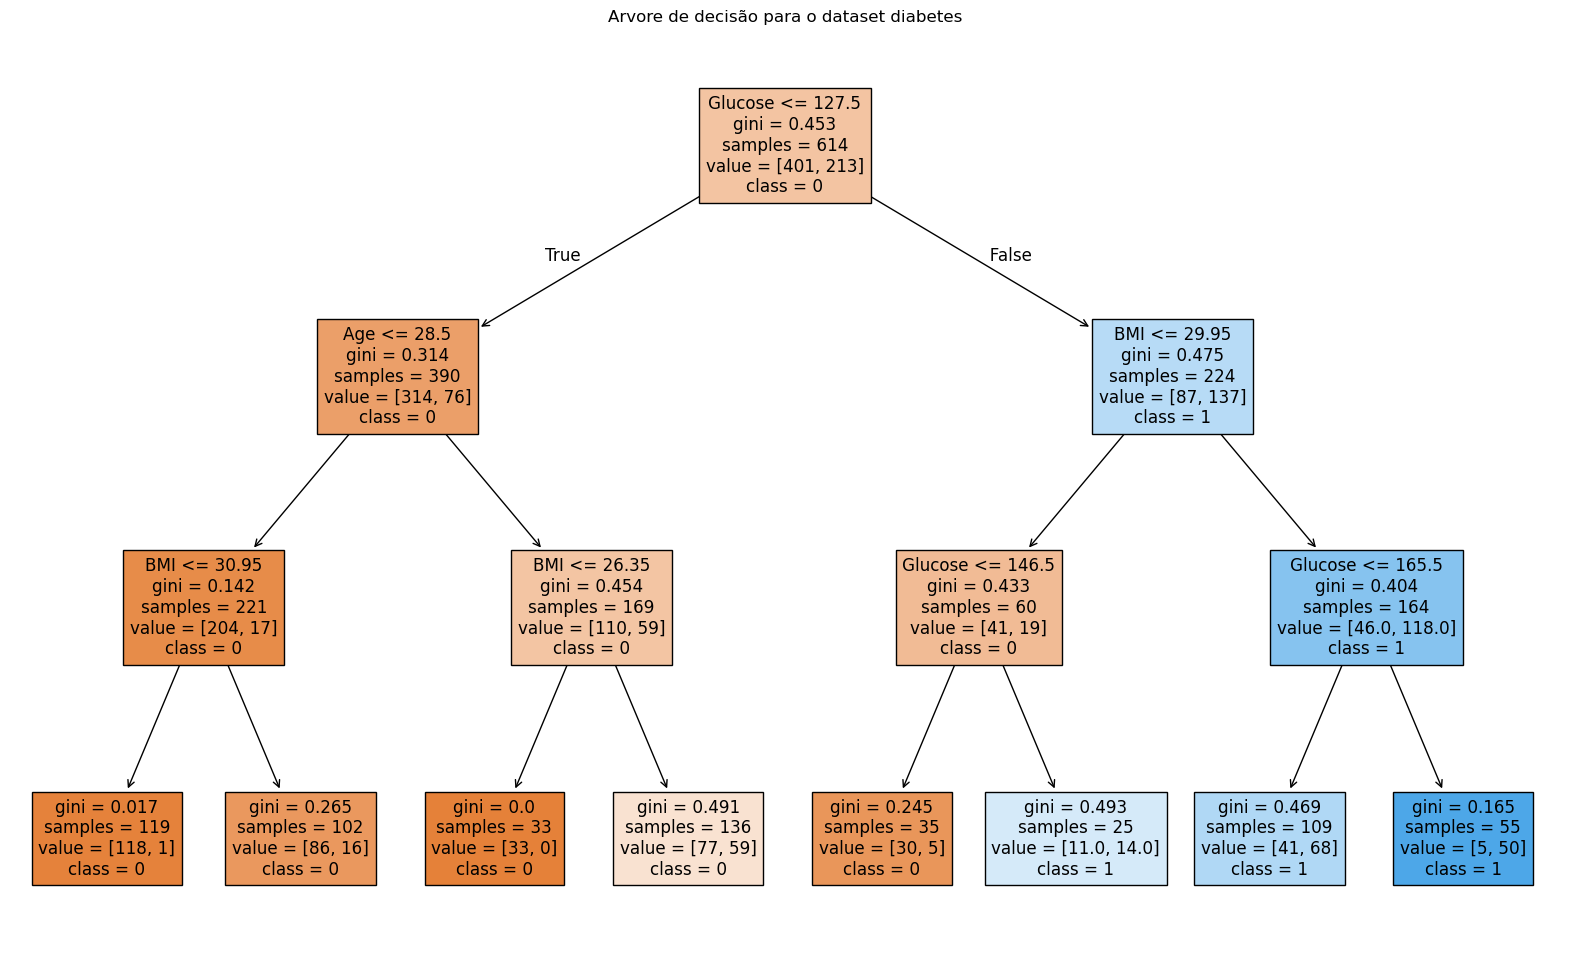

Accuracy (Test): 0.76
Accuracy (Train): 0.78


In [70]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,12))
plot_tree(clf, filled=True, feature_names = x.columns, class_names = ['0','1'])
plt.title('Arvore de decisão para o dataset diabetes')
plt.show()

accuracy = np.mean(y_pred == y_test)
accuracy_train = np.mean(clf.predict(x_train) == y_train)
print(f'Accuracy (Test): {accuracy:.2f}')
print(f'Accuracy (Train): {accuracy_train:.2f}')

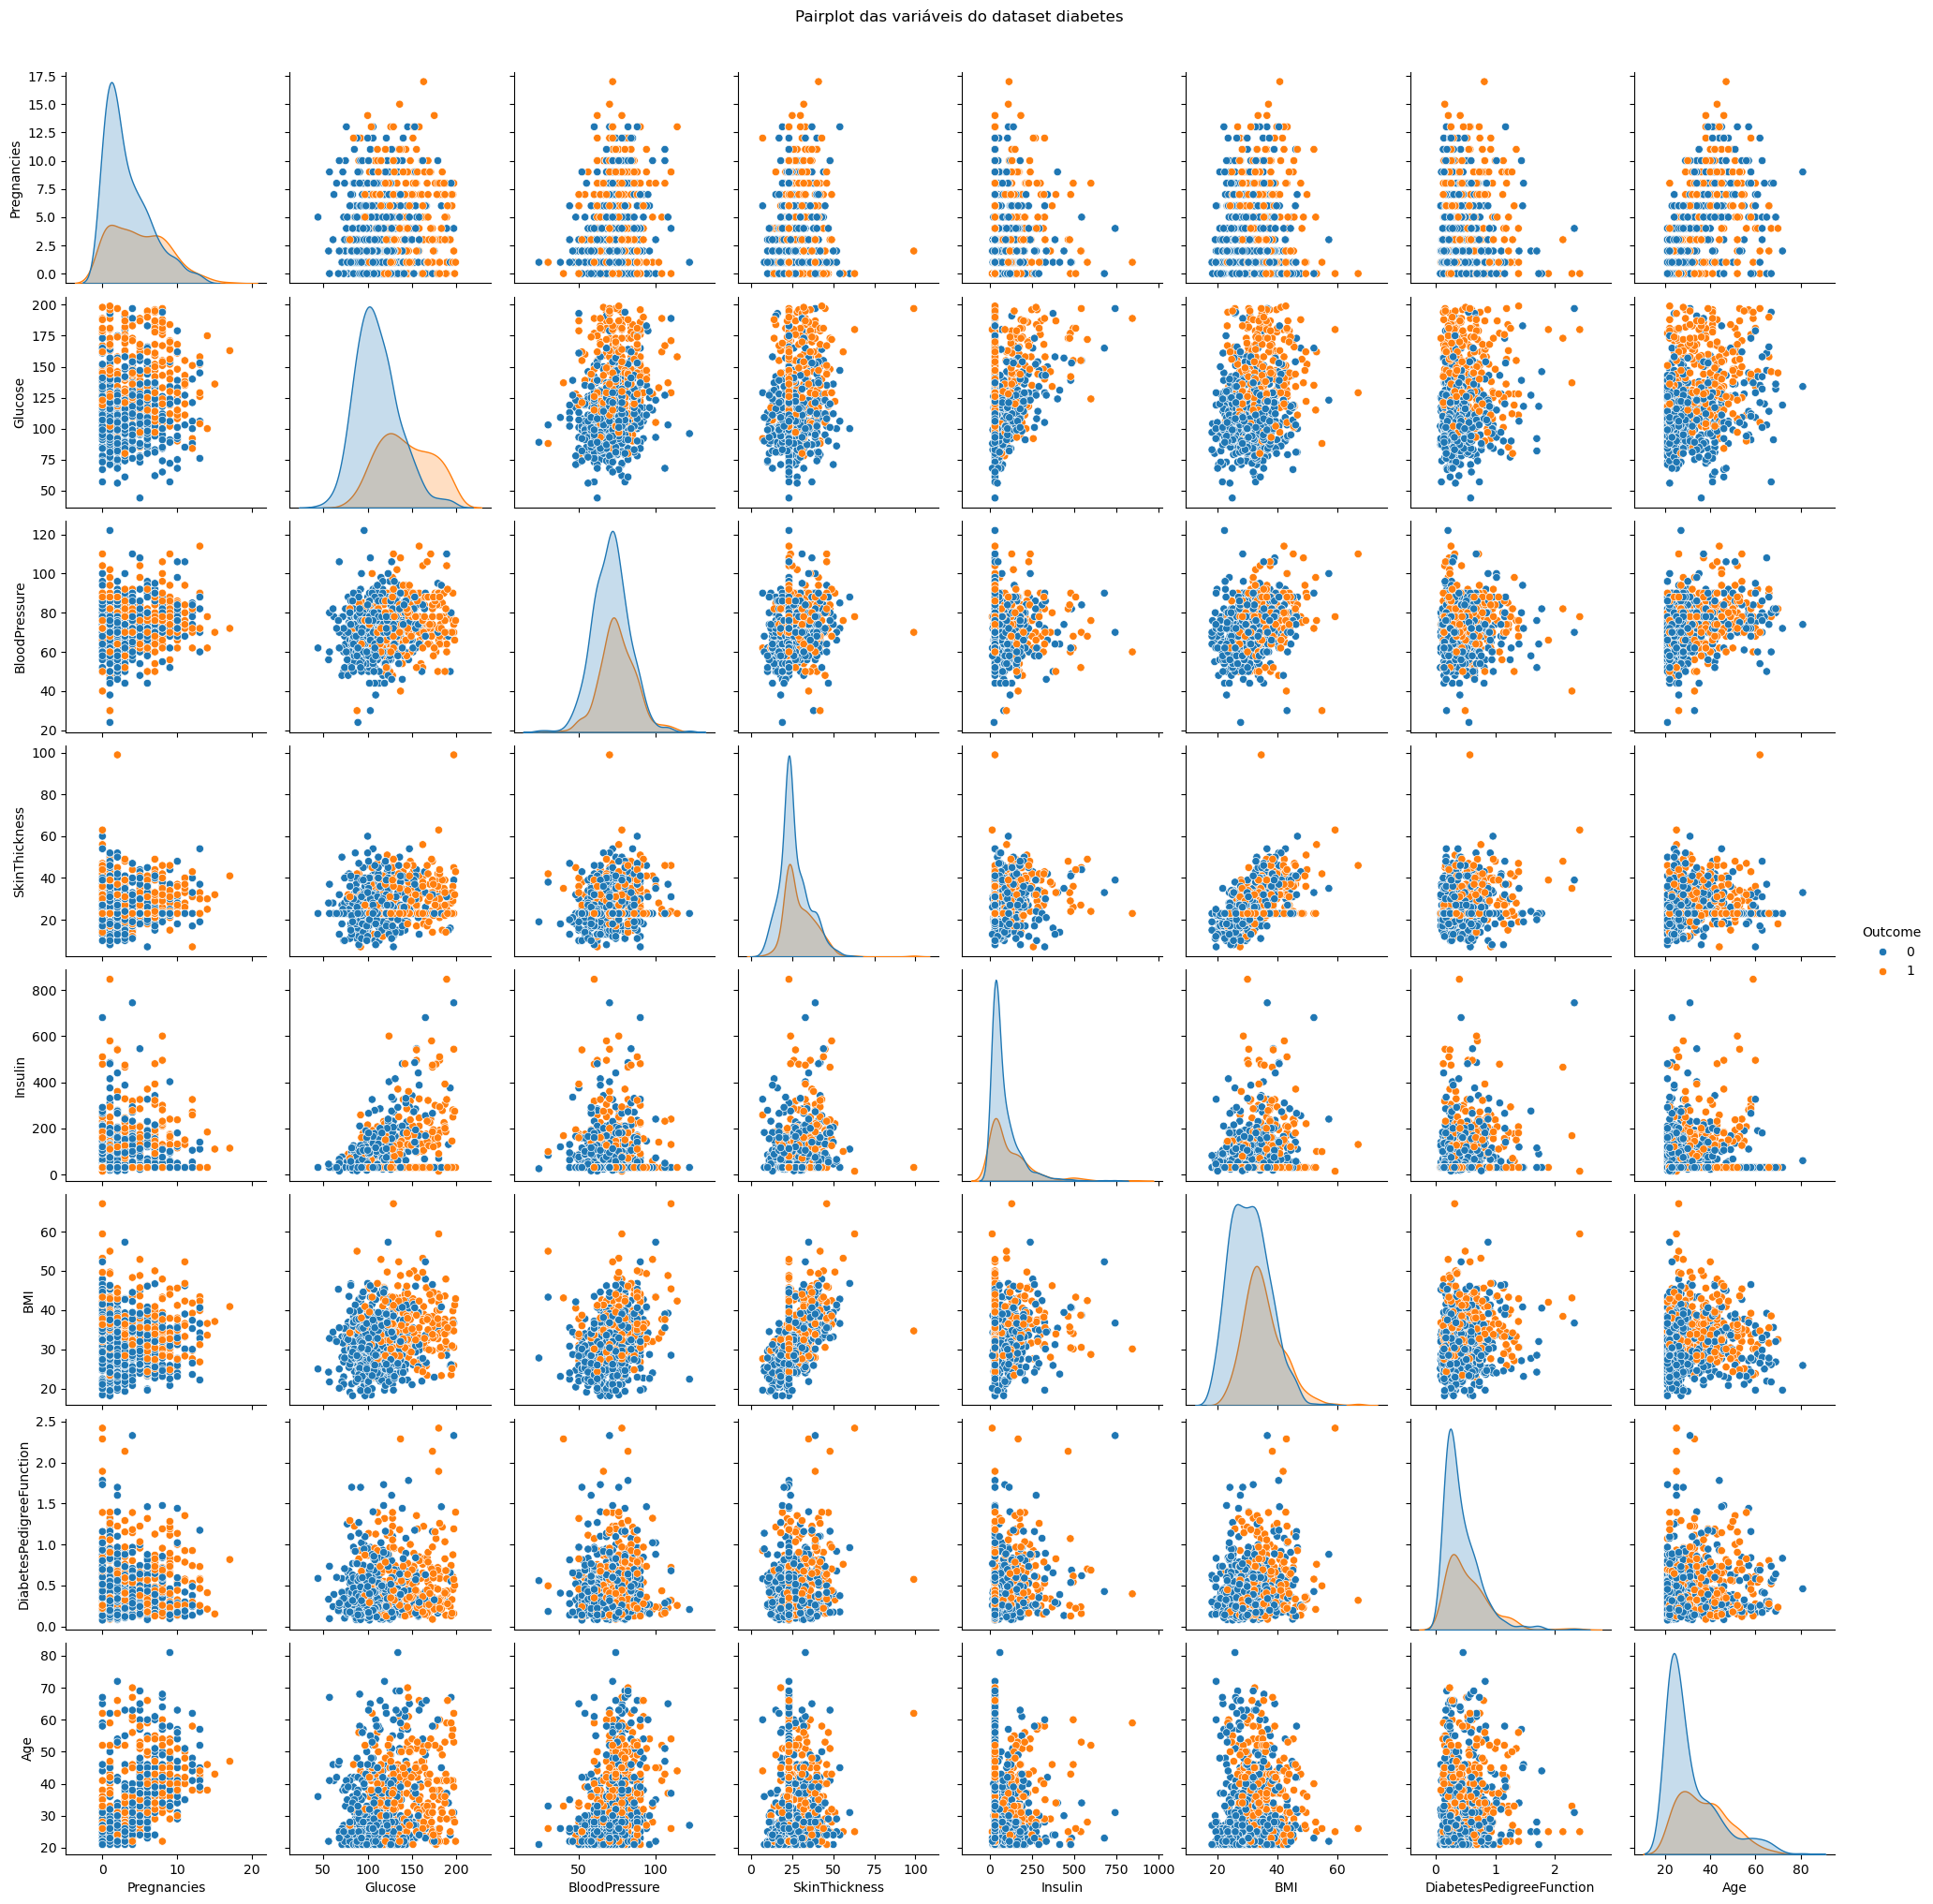

In [71]:
import seaborn as sns

pairplot = sns.pairplot(df, hue ='Outcome')
pairplot.fig.suptitle('Pairplot das variáveis do dataset diabetes', y = 1.02)
plt.show()


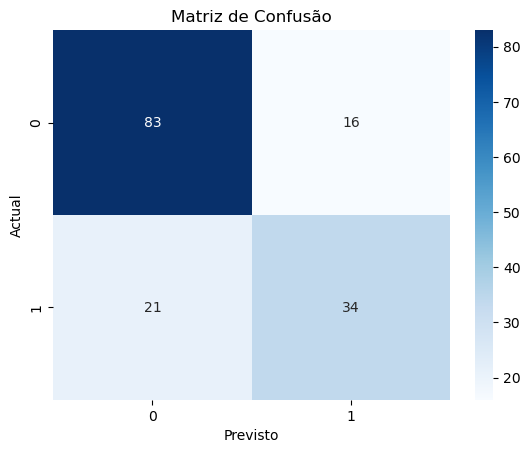

In [72]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Previsto')
plt.ylabel('Actual')
plt.title('Matriz de Confusão')
plt.show()

